In [1]:
import psycopg2
print("psycopg2 works")

psycopg2 works


In [2]:
import pandas as pd
from sqlalchemy import create_engine

In [3]:
DB_USER = "postgres"
DB_PASSWORD = "Itis0077##"
DB_HOST = "localhost"
DB_PORT = "5433"
DB_NAME = "churn_db"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [4]:
df = pd.read_sql("SELECT * FROM churn_ml_ready;", engine)
df.columns = df.columns.str.lower()

df.select_dtypes(include="object").nunique().sort_values(ascending=False)

customer_id          7043
total_charges        6531
lat_long             1652
city                 1129
churn_reason           20
payment_method          4
online_backup           3
contract                3
streaming_movies        3
streaming_tv            3
tech_support            3
device_protection       3
online_security         3
internet_service        3
multiple_lines          3
tenure_group            3
phone_service           2
dependents              2
partner                 2
paperless_billing       2
senior_citizen          2
gender                  2
churn_label             2
country                 1
state                   1
dtype: int64

In [5]:
df = pd.read_sql("SELECT * FROM churn_ml_ready;", engine)
df.columns = df.columns.str.lower()

# drop leakage, IDs, location, and high-cardinality text columns
drop_cols = [
    "customerid",
    "customer_id",
    "churn_label",
    "churn_reason",
    "churn_score",
    "cltv",
    "count",
    "country",
    "state",
    "city",
    "zip_code",
    "lat_long",
    "latitude",
    "longitude",
    "total_charges
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

X = df.drop("churn_value", axis=1)
y = df["churn_value"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(7043, 36)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

## Gradient Boosting Classifier

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

## Support Vector Classifier

In [10]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

## Metrics 

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [12]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))

In [13]:
evaluate_model("Decision Tree", y_test, dt_predictions)

evaluate_model("Gradient Boosting", y_test, gb_predictions)

evaluate_model("Support Vector Machine", y_test, svm_predictions)


Decision Tree
----------------------------------------
Accuracy : 0.7935
Precision: 0.6078
Recall   : 0.6257
F1 Score : 0.6166

Gradient Boosting
----------------------------------------
Accuracy : 0.807
Precision: 0.6667
Recall   : 0.5455
F1 Score : 0.6

Support Vector Machine
----------------------------------------
Accuracy : 0.8048
Precision: 0.6813
Recall   : 0.4973
F1 Score : 0.575


In [14]:
results = []

models = [
    ("Decision Tree", dt_model, X_test, dt_predictions),
    ("Gradient Boosting", gb_model, X_test, gb_predictions),
    ("Support Vector Machine", svm_model, X_test_scaled, svm_predictions)
]

for name, model, X_eval, preds in models:

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_eval)[:, 1]
    else:
        probs = model.decision_function(X_eval)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC AUC": roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results)

results_df.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Decision Tree,0.793471,0.607792,0.625668,0.616601,0.843508
1,Gradient Boosting,0.806955,0.666667,0.545455,0.600000,0.855966
2,Support Vector Machine,0.804826,0.681319,0.497326,0.574961,0.811088


## K-Means

In [15]:
from sklearn.cluster import KMeans


In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

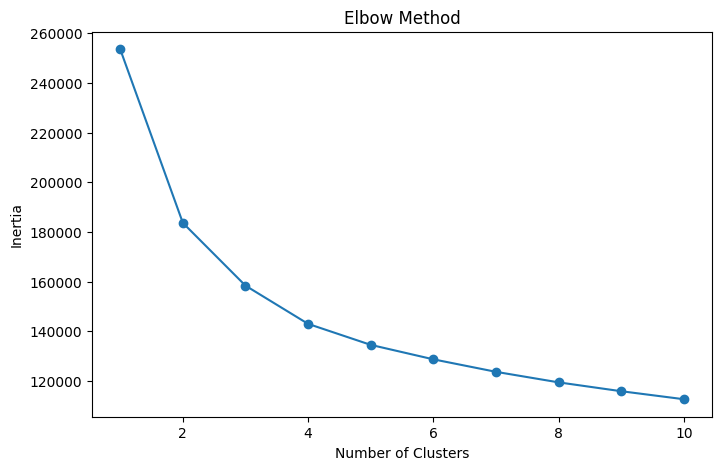

In [17]:
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [18]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [19]:
df["Cluster"] = clusters

In [20]:
df["Cluster"].value_counts()

Cluster
3    2778
2    2057
1    1526
0     682
Name: count, dtype: int64

In [21]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,tenure_months,monthly_charges,churn_value,estimated_revenue,month_to_month_flag,fiber_flag,electronic_check_flag,no_tech_support_flag
Cluster,,,,,,,,
0,31.737537,42.028592,0.249267,1495.745455,0.551320,0.000000,0.331378,0.576246
1,30.547182,21.079194,0.074050,661.943119,0.343381,0.000000,0.079948,0.000000
2,55.506077,89.539281,0.117161,5044.643899,0.150705,0.569276,0.217307,0.357316
3,16.398128,75.991343,0.484161,1313.187671,0.959323,0.692945,0.565155,0.844132


## PCA

In [22]:
from sklearn.decomposition import PCA

In [23]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [24]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": clusters
})

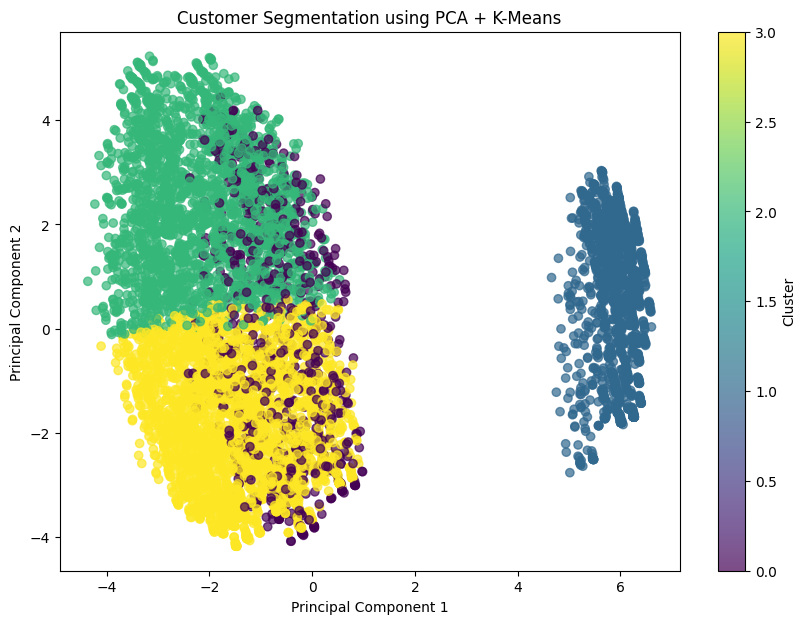

In [25]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("Customer Segmentation using PCA + K-Means")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [26]:
df_powerbi = df.copy()

df_powerbi.to_csv("churn_powerbi_data.csv", index=False)